In [1]:
import xarray as xr
import pandas as pd
import numpy as np
import calendar as cld
import matplotlib.pyplot as plt
import matplotlib.colors
colors_land = plt.cm.terrain(np.linspace(0.25, 1, 256))
import proplot as pplt # New plot library (https://proplot.readthedocs.io/en/latest/)
pplt.rc['savefig.dpi'] = 300 # 1200 is too big! #https://proplot.readthedocs.io/en/latest/basics.html#Creating-figures
from scipy.stats import chi2
from numba import njit,prange
import matplotlib as mpl
mpl.rcParams['hatch.linewidth'] = 0.05  # previous pdf hatch linewidth
from matplotlib.dates import DateFormatter

from scipy.stats import linregress

In [2]:
normal_format = {'gridlinewidth':0.1, 'gridcolor':'gray8', 'gridalpha':0.5, 'coast':True,'borders':True ,'reso':'hi', 'labels':True, 'lonlines':2, 'latlines':2, 'abc':False, 'latlim':[43.,48.5],'lonlim':[4.,16.]}
multiplot_format = {'gridlinewidth':0.1, 'gridcolor':'gray8', 'gridalpha':0.5, 'coast':True,'borders':True ,'reso':'hi', 'labels':False, 'lonlines':2, 'latlines':2, 'abc':False, 'latlim':[43.,48.5],'lonlim':[4.,16.]}

imin = 32 ; imax = -30
jmin = 20 ; jmax = -15
ds = xr.open_dataset('/bettik/beaumetj/MARout/MAR-ERA-20C/MARgrid_EUf.nc')
lon = ds.LON[jmin:jmax,imin:imax]
lat = ds.LAT[jmin:jmax,imin:imax]
H = np.array(ds.SH[jmin:jmax,imin:imax])

In [3]:
wp_meanseason_meanT = np.load('/bettik/castelli/data/saved_data_MAR_ECEarth3/wp_meanseason_meanT.npy')[:,:,jmin:jmax,imin:imax]
origin_T=np.full(wp_meanseason_meanT.shape[1:4],np.nan)
slope_T=np.full(wp_meanseason_meanT.shape[1:4],np.nan)
pvalue_T=np.full(wp_meanseason_meanT.shape[1:4],np.nan)
for i in range(wp_meanseason_meanT.shape[3]):
    # print(str(lon)+'/'+str(les_season_maxT.shape[3]),end=' ')
    for j in range(wp_meanseason_meanT.shape[2]):
        for season in range(4):
            linregress_T = linregress(np.arange(wp_meanseason_meanT.shape[0]), wp_meanseason_meanT[:,season,j,i])
            origin_T[season][j][i] = linregress_T.intercept
            slope_T[season][j][i] = linregress_T.slope
            pvalue_T[season][j][i] = linregress_T.pvalue

In [4]:
wp_meanseason_meanT_hist = wp_meanseason_meanT[:54,:,:,:]
wp_meanseason_meanT_fut = wp_meanseason_meanT[55:,:,:,:]

origin_T_hist=np.full(wp_meanseason_meanT_hist.shape[1:4],np.nan)
slope_T_hist=np.full(wp_meanseason_meanT_hist.shape[1:4],np.nan)
pvalue_T_hist=np.full(wp_meanseason_meanT_hist.shape[1:4],np.nan)

origin_T_fut=np.full(wp_meanseason_meanT_fut.shape[1:4],np.nan)
slope_T_fut=np.full(wp_meanseason_meanT_fut.shape[1:4],np.nan)
pvalue_T_fut=np.full(wp_meanseason_meanT_fut.shape[1:4],np.nan)

for i in range(wp_meanseason_meanT.shape[3]):
    # print(str(lon)+'/'+str(les_season_maxT.shape[3]),end=' ')
    for j in range(wp_meanseason_meanT.shape[2]):
        for season in range(4):
            linregress_T_hist = linregress(np.arange(wp_meanseason_meanT_hist.shape[0]), wp_meanseason_meanT_hist[:,season,j,i])
            origin_T_hist[season][j][i] = linregress_T_hist.intercept
            slope_T_hist[season][j][i] = linregress_T_hist.slope
            pvalue_T_hist[season][j][i] = linregress_T_hist.pvalue
            
            linregress_T_fut = linregress(np.arange(wp_meanseason_meanT_fut.shape[0]), wp_meanseason_meanT_fut[:,season,j,i])
            origin_T_fut[season][j][i] = linregress_T_fut.intercept
            slope_T_fut[season][j][i] = linregress_T_fut.slope
            pvalue_T_fut[season][j][i] = linregress_T_fut.pvalue

In [5]:
def detect_alps(H):
    nlat,nlon = np.shape(H)
    mask = np.bool8(np.zeros((nlat,nlon)))
    r = 4
    for j in range(r,nlat-r):
        for i in range(r,nlon-r):
            mask[j,i] = np.logical_and(H[j,i]>360 ,np.any(H[j-r:j+r,i-r:i+r]>1300))
            # mask[j,i] = np.std(H[j-r:j+r,i-r:i+r])>200
    return mask
alps = detect_alps(H)
alps[lon<4.8] = False
alps[np.logical_and(lon>10,lat<45.2)] = False

north_alps = np.copy(alps)
north_alps[lon>8.6] = False
north_alps[lat<45] = False
#north_alps[lat>46.5] = False

south_alps = np.copy(alps)
south_alps[lat>45] = False

east_alps = np.copy(alps)
east_alps[lon<8.6] = False

/tmp/ipykernel_1798049/4051375370.py:3: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  mask = np.bool8(np.zeros((nlat,nlon)))


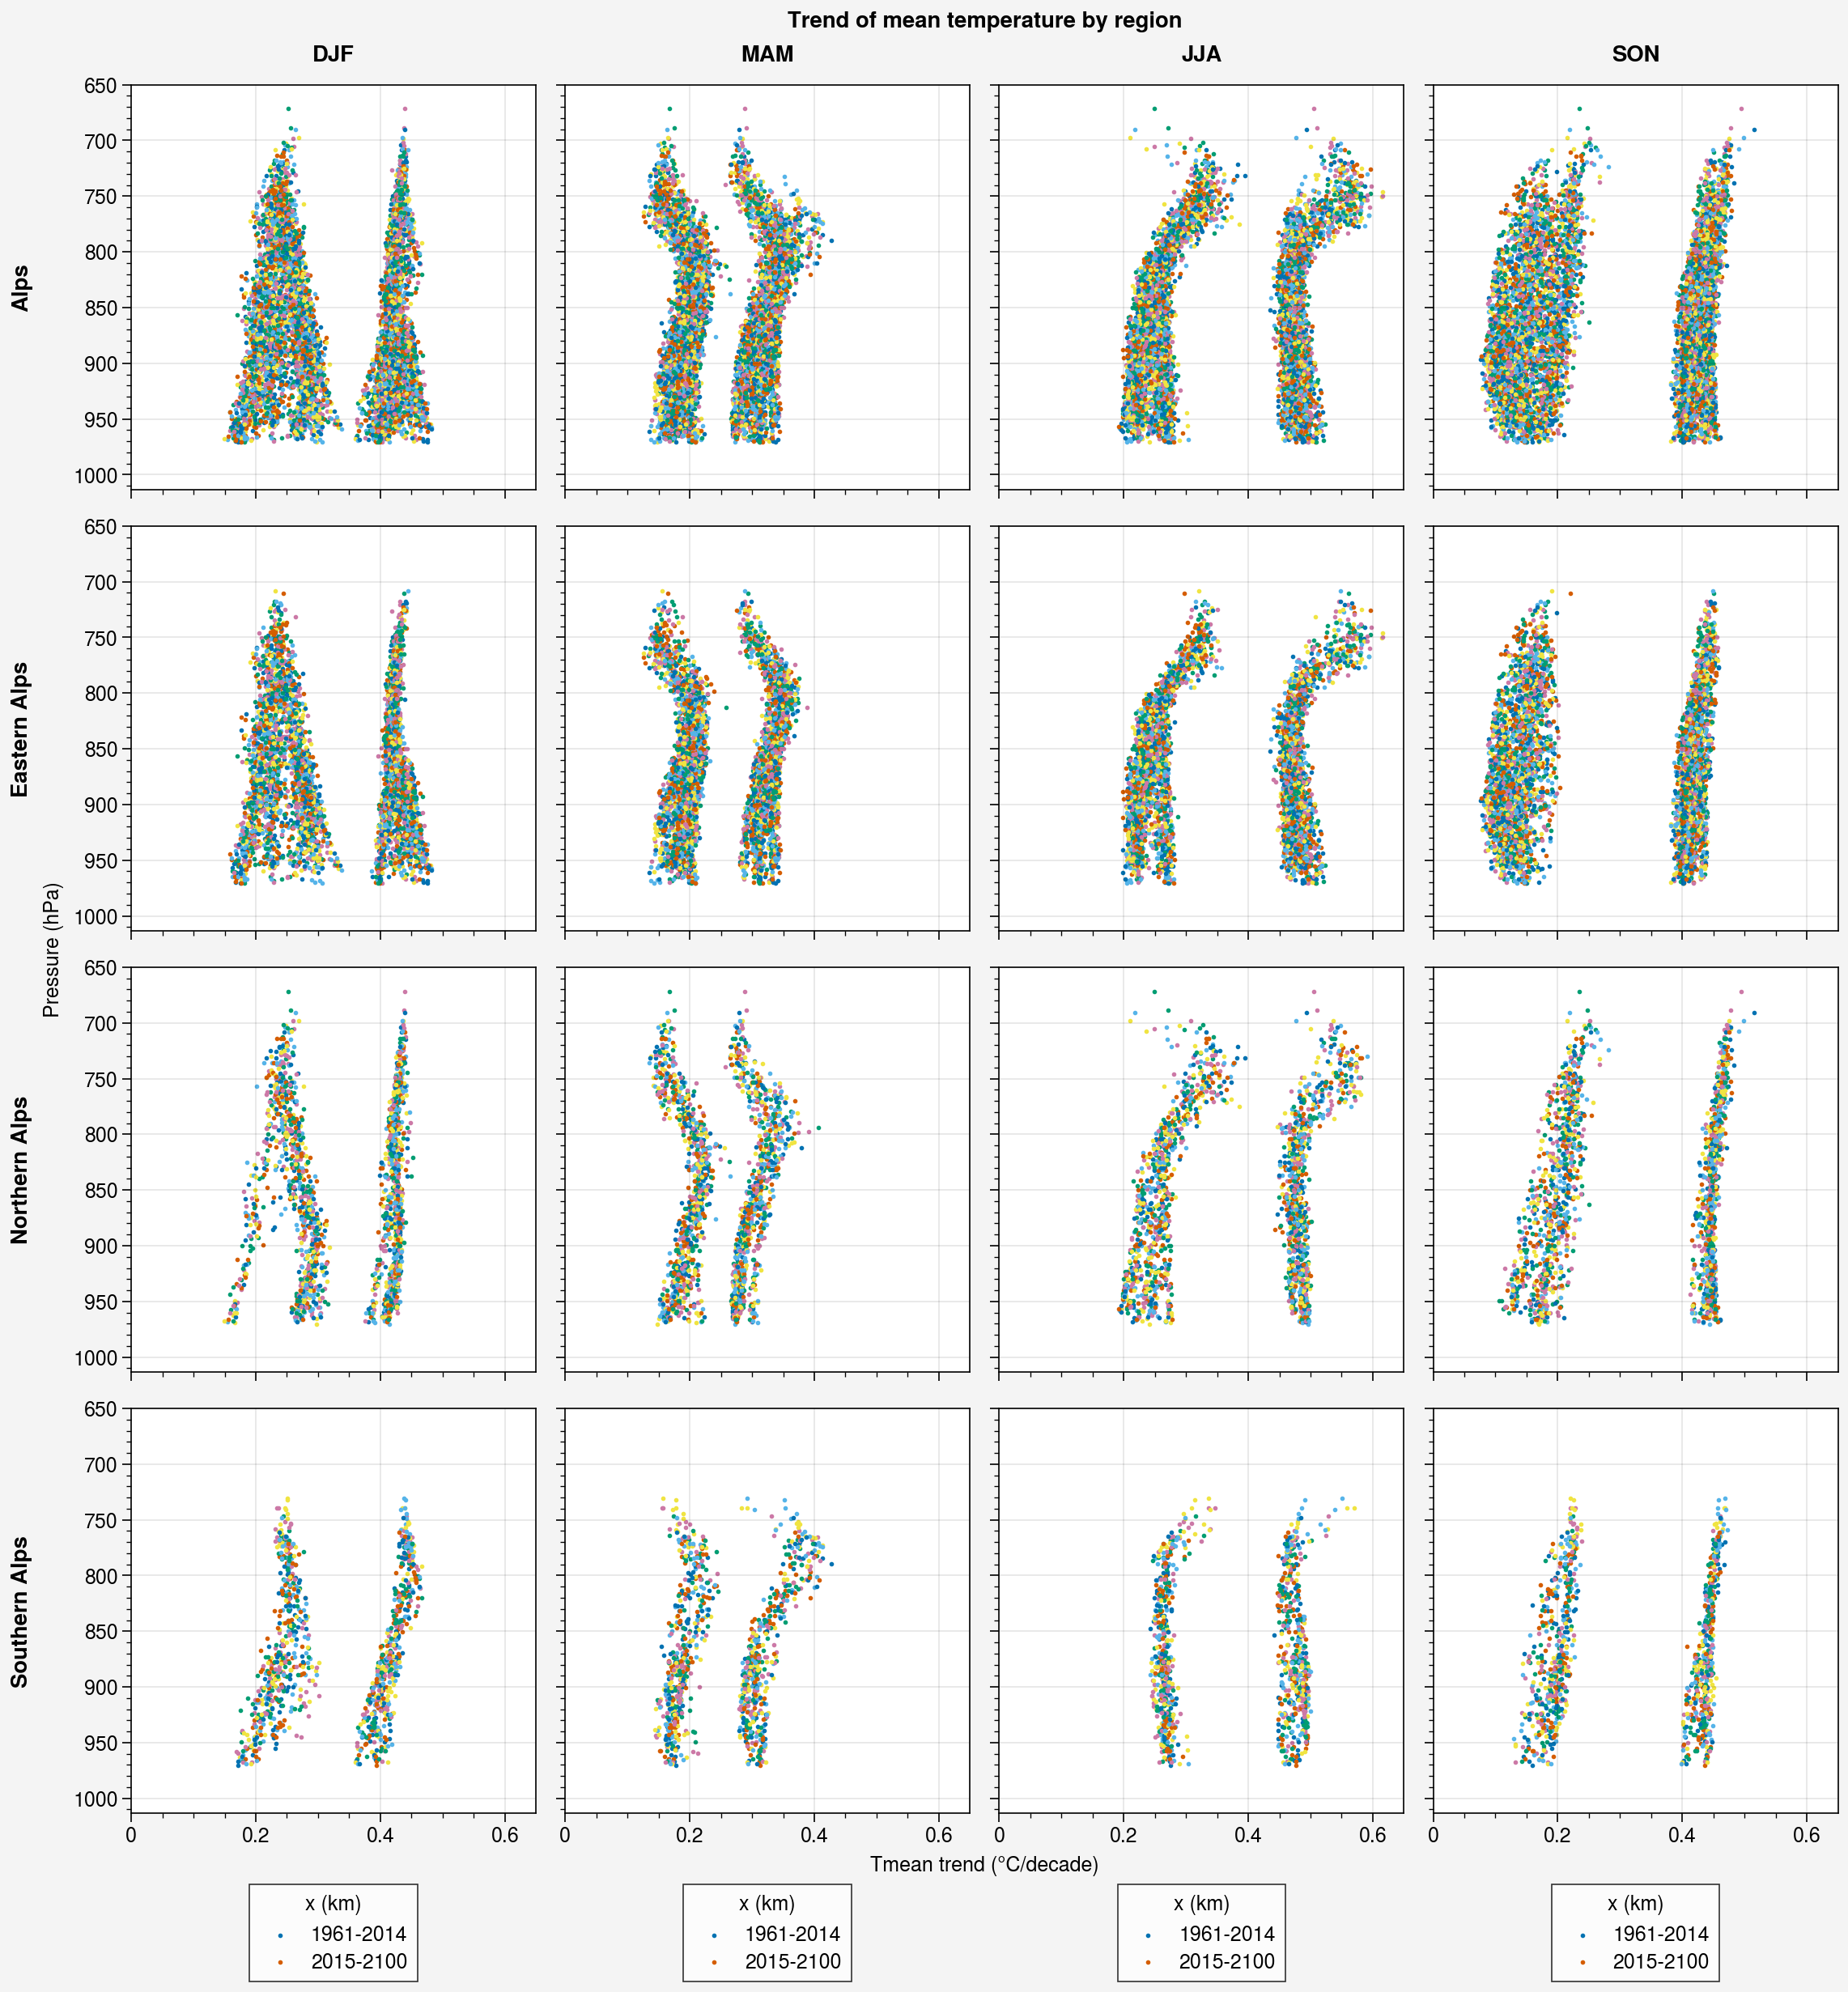

In [6]:
# Ajout de coordonnée verticale pression dans le cas de l'atmosphère standard OACI
def z_to_p(H):
    p0 = 1013.25 # hPa
    gamma = 6.5*10**(-3) # K/m
    T0 = 288.5 # K
    g = 9.81 # m.s^-2
    R = 287 # J/kg/K
    pressure = p0*(1-gamma/T0*H)**(g/gamma/R)
    return pressure

def p_to_z(P):
    p0 = 1013.25 # hPa
    gamma = 6.5*10**(-3) # K/m
    T0 = 288.5 # K
    g = 9.81 # m.s^-2
    R = 287 # J/kg/K
    altitude = T0/gamma*(1-(P/p0)**(gamma*R/g))
    return altitude

f, axs = pplt.subplots(ncols=4, nrows=4)
leg = ['1961-2014','2015-2100']


for i in range(4):
    slope_T_hist_alps = np.ma.masked_array(slope_T_hist[i], mask=np.invert(alps))
    slope_T_hist_east_alps = np.ma.masked_array(slope_T_hist[i], mask=np.invert(east_alps))
    slope_T_hist_north_alps = np.ma.masked_array(slope_T_hist[i], mask=np.invert(north_alps))
    slope_T_hist_south_alps = np.ma.masked_array(slope_T_hist[i], mask=np.invert(south_alps))
    slopes=[slope_T_hist_alps,slope_T_hist_east_alps,slope_T_hist_north_alps,slope_T_hist_south_alps]
    
    for j,slope in enumerate(slopes):
        ax = axs[i+4*j]
        blue_dot = ax.scatter(10*slope,z_to_p(ds.SH[jmin:jmax,imin:imax]),s=2)
        
    
for i in range(4):
    slope_T_fut_alps = np.ma.masked_array(slope_T_fut[i], mask=np.invert(alps))
    slope_T_fut_east_alps = np.ma.masked_array(slope_T_fut[i], mask=np.invert(east_alps))
    slope_T_fut_north_alps = np.ma.masked_array(slope_T_fut[i], mask=np.invert(north_alps))
    slope_T_fut_south_alps = np.ma.masked_array(slope_T_fut[i], mask=np.invert(south_alps))
    slopes=[slope_T_fut_alps,slope_T_fut_east_alps,slope_T_fut_north_alps,slope_T_fut_south_alps]
    
    for j,slope in enumerate(slopes):
        ax = axs[i+4*j]
        orange_dot = ax.scatter(10*slope,z_to_p(ds.SH[jmin:jmax,imin:imax]),s=2)
        ax.set_xlim((0.,0.65))
        ax.set_ylim((1013.25,650))
        #ax.dualy(z_to_p,yscale='log')
        if(j==3):
            ax.legend([blue_dot,orange_dot],leg,loc='bottom')

axs.format(suptitle='Trend of mean temperature by region',collabels=['DJF','MAM','JJA', 'SON'],
           rowlabels=['Alps','Eastern Alps','Northern Alps','Southern Alps'],xlabel='Tmean trend (°C/decade)',ylabel='Pressure (hPa)')

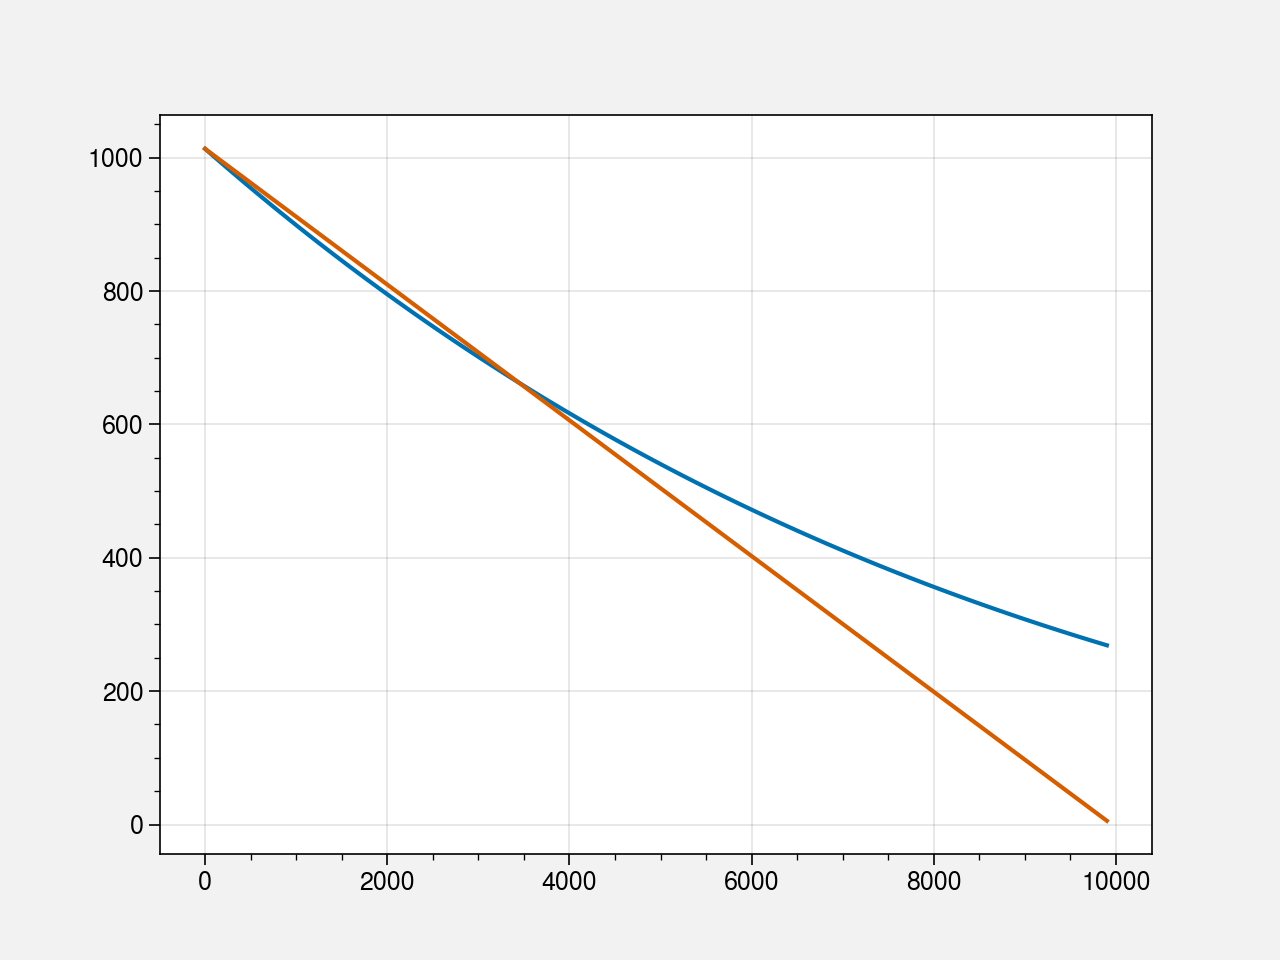

In [8]:
p0 = 1013.25 # hPa
gamma = 6.5*10**(-3) # K/m
T0 = 288.5 # K
g = 9.81 # m.s^-2
R = 287 # J/kg/K
rho = 1.225 #kg/m^3

altitude = np.arange(0,10000,100)
pressure = p0*(1-gamma/T0*altitude)**(g/gamma/R)
pressure2 = p0*np.exp(-g*altitude/R/T0)
pressure3 = p0 - (rho*g*altitude)/100
fiction = p0 - (p0-657)/3500*altitude

plt.plot(altitude,pressure)
#plt.plot(altitude,pressure2)
#plt.plot(altitude,pressure3)
plt.plot(altitude,fiction)

In [9]:
altitude = 3500
pressure = p0*(1-gamma/T0*altitude)**(g/gamma/R)
pressure2 = p0*np.exp(-g*altitude/R/T0)
pressure3 = p0 - (rho*g*altitude)/100

print(pressure,pressure2,pressure3)

657.8508023105202 669.3063304525241 592.64625


(0.0, 3500.0)

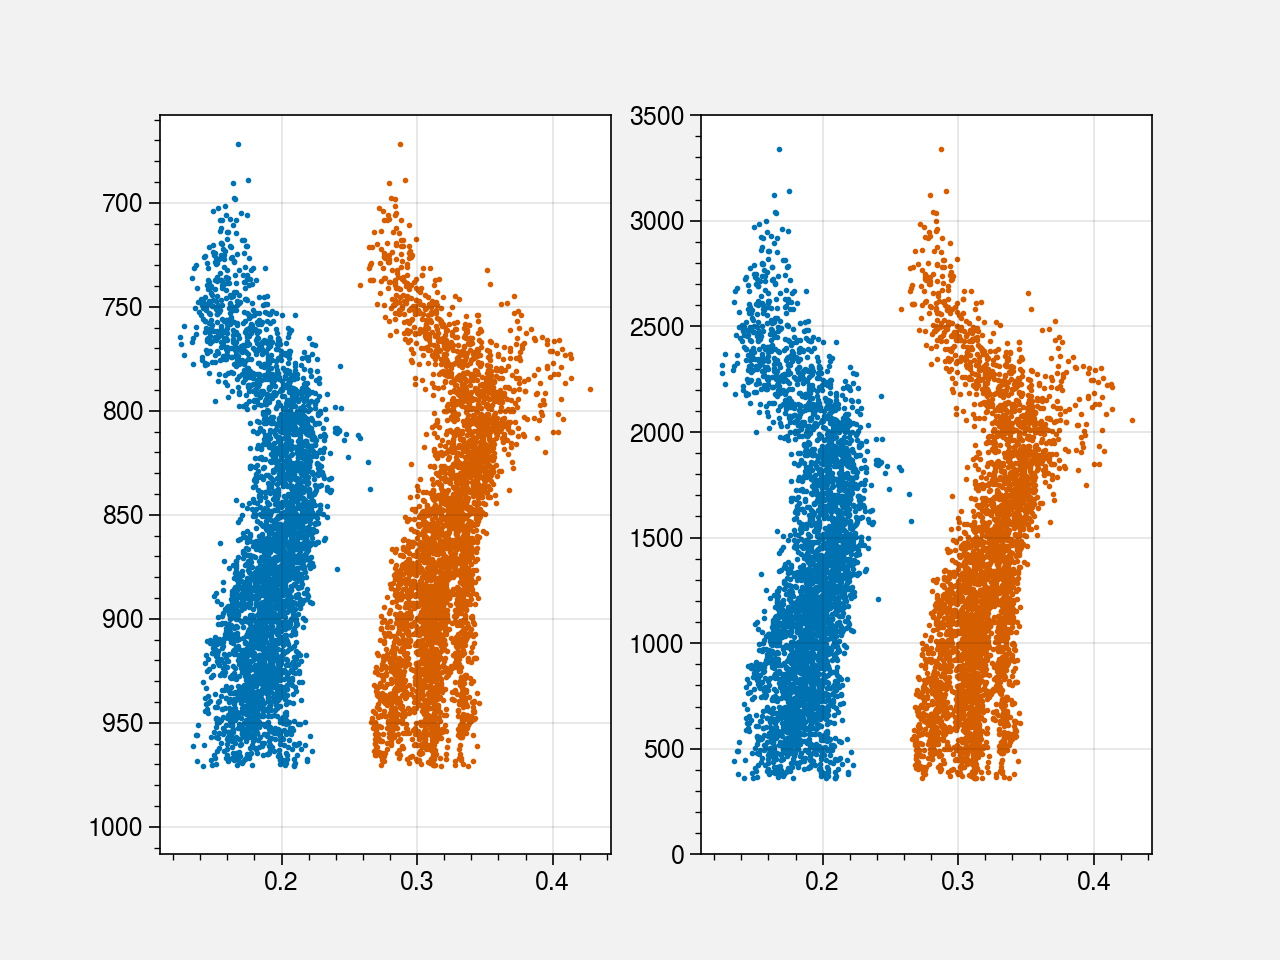

In [10]:
f, axs = plt.subplots(ncols=2)
leg = ['1961-2014','2015-2100']

ax = axs[0]
blue_dot = ax.scatter(10*np.ma.masked_array(slope_T_hist[1], mask=np.invert(alps)),z_to_p(ds.SH[jmin:jmax,imin:imax]),s=2)
orange_dot = ax.scatter(10*np.ma.masked_array(slope_T_fut[1], mask=np.invert(alps)),z_to_p(ds.SH[jmin:jmax,imin:imax]),s=2)
ax.set_ylim((1013.25,657.85))

ax = axs[1]
blue_dot = ax.scatter(10*np.ma.masked_array(slope_T_hist[1], mask=np.invert(alps)),ds.SH[jmin:jmax,imin:imax],s=2)
orange_dot = ax.scatter(10*np.ma.masked_array(slope_T_fut[1], mask=np.invert(alps)),ds.SH[jmin:jmax,imin:imax],s=2)
ax.set_ylim((0,3500))